In [1]:
from rdkit import Chem, RDLogger

RDLogger.DisableLog('rdApp.*')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

import warnings
warnings.filterwarnings('ignore')

# Optional GPU acceleration (RAPIDS)
GPU_AVAILABLE = False
GPU_BACKEND = 'CPU (scikit-learn)'
cp = None
cuLinearRegression = None
try:
    import cupy as cp
    from cuml.linear_model import LinearRegression as cuLinearRegression
    GPU_AVAILABLE = True
    GPU_BACKEND = 'GPU (RAPIDS cuML)'
except Exception:
    pass

# Local utilities
import sys
sys.path.insert(0, '.')

random_state = 0

from pathlib import Path
MAIN_DIR = Path().resolve().parent.parent
PATH_DATA = MAIN_DIR / 'data' / 'processed'

In [2]:
df = pd.read_csv(PATH_DATA / 'train.csv')
df_val = pd.read_csv(PATH_DATA / 'valid.csv')
df_test = pd.read_csv(PATH_DATA / 'test.csv')
print(f'Compute backend: {GPU_BACKEND}')
if not GPU_AVAILABLE:
    print('GPU non rilevata o librerie RAPIDS mancanti. Uso CPU.')

Compute backend: CPU (scikit-learn)
GPU non rilevata o librerie RAPIDS mancanti. Uso CPU.


## Exploratory Data Analysis (EDA)

In [3]:
# Basic dataset info
print(f"Dataset Shape: {df.shape}")
print(f"\nMissing Values: {df.isnull().sum().sum()} total")
print("\nTarget Column (LD50) Stats:")
print(df['Y'].describe())

Dataset Shape: (5169, 1817)

Missing Values: 0 total

Target Column (LD50) Stats:
count    5169.000000
mean        2.472342
std         0.927154
min        -0.343000
25%         1.804000
50%         2.314000
75%         2.951000
max         7.100000
Name: Y, dtype: float64


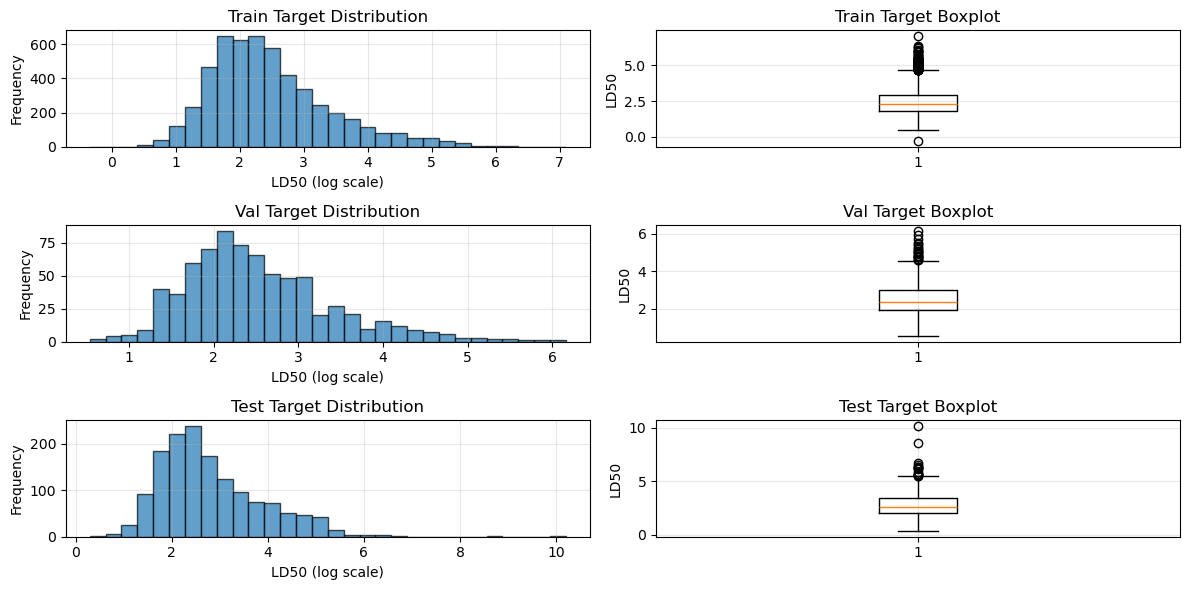

In [4]:
# Target distribution
fig, axes = plt.subplots(3, 2, figsize=(12, 6))
axes = axes.ravel()

axes[0].hist(df['Y'], bins=30, alpha=0.7, edgecolor='black')
axes[0].set_xlabel('LD50 (log scale)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Train Target Distribution')
axes[0].grid(alpha=0.3)

axes[1].boxplot(df['Y'], vert=True)
axes[1].set_ylabel('LD50')
axes[1].set_title('Train Target Boxplot')
axes[1].grid(alpha=0.3)

axes[2].hist(df_val['Y'], bins=30, alpha=0.7, edgecolor='black')
axes[2].set_xlabel('LD50 (log scale)')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Val Target Distribution')
axes[2].grid(alpha=0.3)

axes[3].boxplot(df_val['Y'], vert=True)
axes[3].set_ylabel('LD50')
axes[3].set_title('Val Target Boxplot')
axes[3].grid(alpha=0.3)

axes[4].hist(df_test['Y'], bins=30, alpha=0.7, edgecolor='black')
axes[4].set_xlabel('LD50 (log scale)')
axes[4].set_ylabel('Frequency')
axes[4].set_title('Test Target Distribution')
axes[4].grid(alpha=0.3)

axes[5].boxplot(df_test['Y'], vert=True)
axes[5].set_ylabel('LD50')
axes[5].set_title('Test Target Boxplot')
axes[5].grid(alpha=0.3)


plt.tight_layout()
plt.show()

In [5]:
from rdkit.Chem.Scaffolds import MurckoScaffold

# 1. Funzione scaffold
def get_scaffold(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return MurckoScaffold.MurckoScaffoldSmiles(mol=mol)

# 2. Aggiunta scaffold ai dataset
df['scaffold'] = df['Drug'].apply(get_scaffold)
df_val['scaffold'] = df_val['Drug'].apply(get_scaffold)
df_test['scaffold'] = df_test['Drug'].apply(get_scaffold)

# 3. Set di scaffold
train_scaffolds = set(df['scaffold'])
val_scaffolds = set(df_val['scaffold'])
test_scaffolds = set(df_test['scaffold'])

# 4. Overlap tra set
train_val_overlap = train_scaffolds & val_scaffolds
train_test_overlap = train_scaffolds & test_scaffolds
val_test_overlap = val_scaffolds & test_scaffolds

# 5. Risultati
print("Train scaffold:", len(train_scaffolds))
print("Val scaffold:", len(val_scaffolds))
print("Test scaffold:", len(test_scaffolds))

print("\nOverlap:")
print("Train-Val:", len(train_val_overlap))
print("Train-Test:", len(train_test_overlap))
print("Val-Test:", len(val_test_overlap))

# 6. Jaccard similarity (opzionale ma utile)
def jaccard(a, b):
    return len(a & b) / len(a | b) if len(a | b) > 0 else 0

print("\nJaccard similarity:")
print("Train-Val:", jaccard(train_scaffolds, val_scaffolds))
print("Train-Test:", jaccard(train_scaffolds, test_scaffolds))
print("Val-Test:", jaccard(val_scaffolds, test_scaffolds))

Train scaffold: 809
Val scaffold: 398
Test scaffold: 470

Overlap:
Train-Val: 0
Train-Test: 0
Val-Test: 0

Jaccard similarity:
Train-Val: 0.0
Train-Test: 0.0
Val-Test: 0.0


Top 15 features by |Spearman correlation|:
                      corr           pval  abs_corr
mordred_MIC1      0.461325  7.708383e-271  0.461325
mordred_MIC2      0.445814  6.035587e-251  0.445814
mordred_ATS0m     0.435724  1.503389e-238  0.435724
mordred_ATS0Z     0.435705  1.582844e-238  0.435705
mordred_BCUTp-1h  0.430145  7.127304e-232  0.430145
mordred_ATS1m     0.429985  1.104297e-231  0.429985
mordred_MIC3      0.428077  1.975102e-229  0.428077
mordred_ATS2m     0.423855  1.701154e-224  0.423855
mordred_MIC4      0.422814  2.734286e-223  0.422814
mordred_MIC5      0.420558  1.082922e-220  0.420558
mordred_Xpc-5dv   0.420018  4.512123e-220  0.420018
mordred_Xpc-4dv   0.419408  2.251801e-219  0.419408
mordred_AATS3Z    0.416961  1.372409e-216  0.416961
mordred_ATSC0Z    0.416303  7.627616e-216  0.416303
mordred_AATS3m    0.416243  8.925920e-216  0.416243


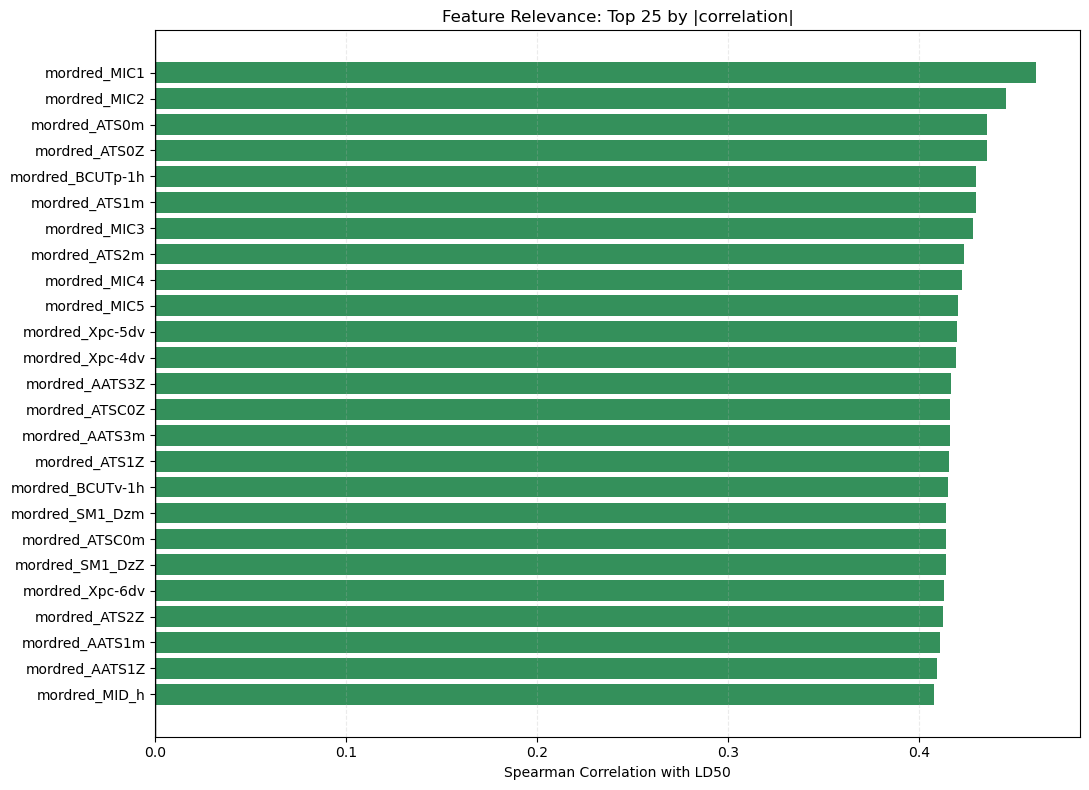

In [6]:
# Feature relevance: Spearman correlations with target
descriptor_cols = df.select_dtypes(include=[np.number]).columns.difference(['Y'])
correlations = {}

for col in descriptor_cols:
    valid_mask = (df[col].notna()) & (df['Y'].notna())
    if valid_mask.sum() > 0:
        corr, pval = spearmanr(df[col][valid_mask], df['Y'][valid_mask])
        correlations[col] = {'corr': corr, 'pval': pval, 'abs_corr': abs(corr)}

corr_df = pd.DataFrame(correlations).T.sort_values('abs_corr', ascending=False)
corr_df_clean = corr_df.dropna(subset=['corr']).copy()

print('Top 15 features by |Spearman correlation|:')
print(corr_df_clean.head(15)[['corr', 'pval', 'abs_corr']])

# Visualization (readable: only top features by absolute correlation)
top_k_plot = 25
plot_df = corr_df_clean.head(top_k_plot).sort_values('corr')
colors = ['#c0392b' if x < 0 else '#1e8449' for x in plot_df['corr']]

fig, ax = plt.subplots(figsize=(11, 8))
ax.barh(plot_df.index, plot_df['corr'], color=colors, alpha=0.9)
ax.set_xlabel('Spearman Correlation with LD50')
ax.set_title(f'Feature Relevance: Top {top_k_plot} by |correlation|')
ax.axvline(0, color='black', linewidth=1)
ax.grid(alpha=0.25, axis='x', linestyle='--')
plt.tight_layout()
plt.show()

Correlation backend: CPU (pandas)


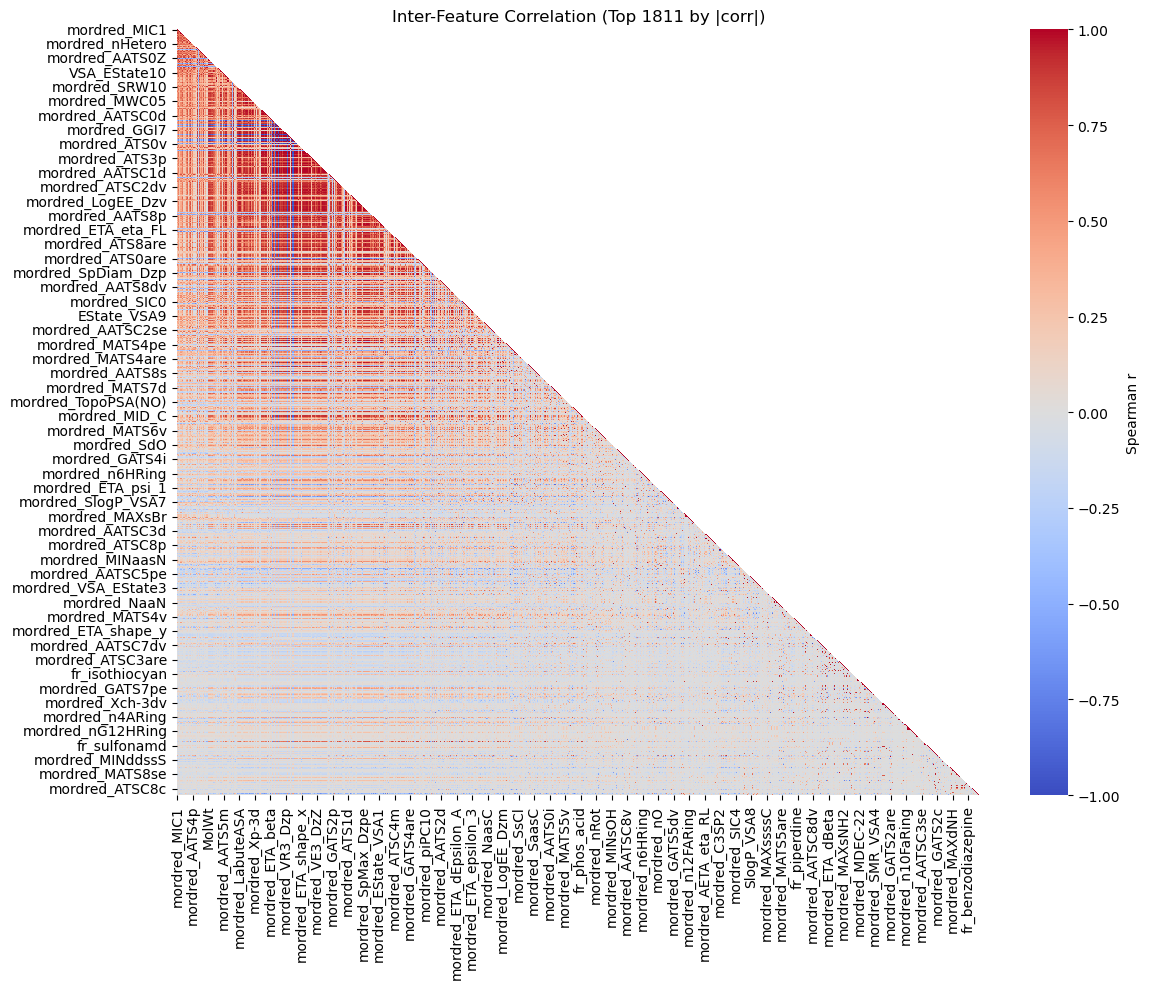


Top highly correlated pairs (|r| > 0.8):
                 feature_a           feature_b  corr
10520          mordred_SMR               MolMR   1.0
57101      mordred_n7HRing    mordred_n7AHRing   1.0
57082     mordred_n4AHRing     mordred_n4HRing   1.0
50755    mordred_PEOE_VSA8           PEOE_VSA8   1.0
57077      mordred_n7ARing      mordred_n7Ring   1.0
57070             SMR_VSA5    mordred_SMR_VSA5   1.0
57064      mordred_n7FRing    mordred_n7FARing   1.0
39291      mordred_SpAbs_A      mordred_SpAD_A   1.0
57054     mordred_n7FHRing   mordred_n7FAHRing   1.0
57049           SlogP_VSA5  mordred_SlogP_VSA5   1.0
57045  mordred_VSA_EState2         VSA_EState2   1.0
57034    mordred_PEOE_VSA4           PEOE_VSA4   1.0
1699        NumHeteroatoms     mordred_nHetero   1.0
54460           fr_halogen          mordred_nX   1.0
3717            ExactMolWt          mordred_MW   1.0


In [7]:
# Inter-feature redundancy check with optional GPU Spearman correlation
top_n = 1811
top_features = corr_df.dropna(subset=['abs_corr']).head(top_n).index.tolist()
df_desc = df[top_features].astype(np.float32)

use_gpu_corr = False
corr_matrix = None

if GPU_AVAILABLE:
    try:
        import cudf
        gdf = cudf.DataFrame.from_pandas(df_desc)
        corr_matrix = gdf.corr(method='spearman').to_pandas()
        use_gpu_corr = True
    except Exception:
        corr_matrix = df_desc.corr(method='spearman')
else:
    corr_matrix = df_desc.corr(method='spearman')

backend_label = 'GPU (cuDF)' if use_gpu_corr else 'CPU (pandas)'
print(f'Correlation backend: {backend_label}')

# Heatmap with upper-triangle mask for readability
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=False,
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    ax=ax,
    cbar_kws={'label': 'Spearman r'}
)
ax.set_title(f'Inter-Feature Correlation (Top {top_n} by |corr|)')
plt.tight_layout()
plt.show()

# Identify strongest correlated pairs
pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        if abs(val) > 0.8:
            pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], float(val), abs(float(val))))

pairs_df = pd.DataFrame(pairs, columns=['feature_a', 'feature_b', 'corr', 'abs_corr'])
if len(pairs_df) > 0:
    print('\nTop highly correlated pairs (|r| > 0.8):')
    print(pairs_df.sort_values('abs_corr', ascending=False).head(15)[['feature_a', 'feature_b', 'corr']])
else:
    print('\nNo feature pairs above |r| > 0.8 in selected subset.')

Top 20 coefficients by absolute magnitude:
            Feature   Coefficient      Abs_Coef
33              Ipc  3.335355e-21  3.335355e-21
521   mordred_ATS8i  5.865587e-37  5.865587e-37
527   mordred_ATS8v  5.469610e-37  5.469610e-37
510   mordred_ATS7i  5.374428e-37  5.374428e-37
516   mordred_ATS7v  5.347126e-37  5.347126e-37
505   mordred_ATS6v  4.728408e-37  4.728408e-37
499   mordred_ATS6i  4.232851e-37  4.232851e-37
494   mordred_ATS5v  4.136112e-37  4.136112e-37
488   mordred_ATS5i  3.779328e-37  3.779328e-37
1           BertzCT  3.761582e-37  3.761582e-37
483   mordred_ATS4v  3.693124e-37  3.693124e-37
477   mordred_ATS4i  3.433092e-37  3.433092e-37
472   mordred_ATS3v  3.117162e-37  3.117162e-37
466   mordred_ATS3i  2.579014e-37  2.579014e-37
461   mordred_ATS2v  2.333626e-37  2.333626e-37
522   mordred_ATS8m  1.942017e-37  1.942017e-37
511   mordred_ATS7m  1.885043e-37  1.885043e-37
455   mordred_ATS2i  1.831886e-37  1.831886e-37
1573  mordred_WPath  1.796627e-37  1.796627e-

findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeOneSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeTwoSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeThreeSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFourSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFiveSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmsy10'] not

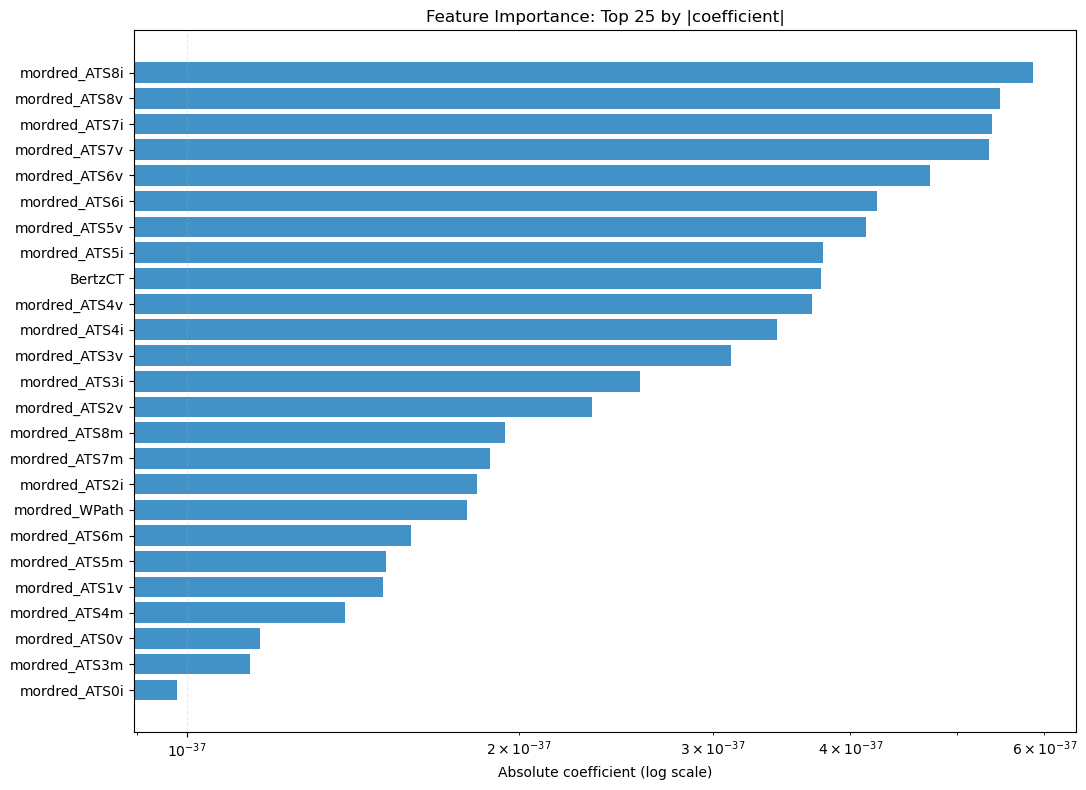

In [8]:
# Feature importance via Linear Regression (GPU if available)
X = df[descriptor_cols].fillna(df[descriptor_cols].mean())
y = df['Y']

if GPU_AVAILABLE:
    # Train on GPU with cuML
    X_gpu = cp.asarray(X.values, dtype=cp.float32)
    y_gpu = cp.asarray(y.values, dtype=cp.float32)
    lr = cuLinearRegression()
    lr.fit(X_gpu, y_gpu)
    y_pred = lr.predict(X_gpu)
    coefs = cp.asnumpy(lr.coef_).ravel()
    model_r2 = float(r2_score(cp.asnumpy(y_gpu), cp.asnumpy(y_pred)))
else:
    # CPU fallback
    lr = LinearRegression()
    lr.fit(X, y)
    coefs = lr.coef_
    model_r2 = float(lr.score(X, y))

coef_df = pd.DataFrame({
    'Feature': descriptor_cols,
    'Coefficient': coefs,
    'Abs_Coef': np.abs(coefs)
}).sort_values('Abs_Coef', ascending=False)

print('Top 20 coefficients by absolute magnitude:')
print(coef_df.head(20)[['Feature', 'Coefficient', 'Abs_Coef']])
print(f'\nModel R² Score: {model_r2:.4f}')

# Visualization: use log scale and avoid single dominant coefficient flattening everything
top_k_coef = 25
plot_coef = coef_df.head(top_k_coef).copy()

if len(plot_coef) > 1 and plot_coef.iloc[0]['Abs_Coef'] > 20 * plot_coef.iloc[1]['Abs_Coef']:
    print('\nNote: dominant first coefficient detected; plotting next top coefficients for readability.')
    plot_coef = coef_df.iloc[1:top_k_coef + 1].copy()

plot_coef = plot_coef.sort_values('Abs_Coef')
fig, ax = plt.subplots(figsize=(11, 8))
ax.barh(plot_coef['Feature'], plot_coef['Abs_Coef'], color='#2e86c1', alpha=0.9)
ax.set_xscale('log')
ax.set_xlabel('Absolute coefficient (log scale)')
ax.set_title(f'Feature Importance: Top {len(plot_coef)} by |coefficient|')
ax.grid(alpha=0.25, axis='x', linestyle='--')
plt.tight_layout()
plt.show()

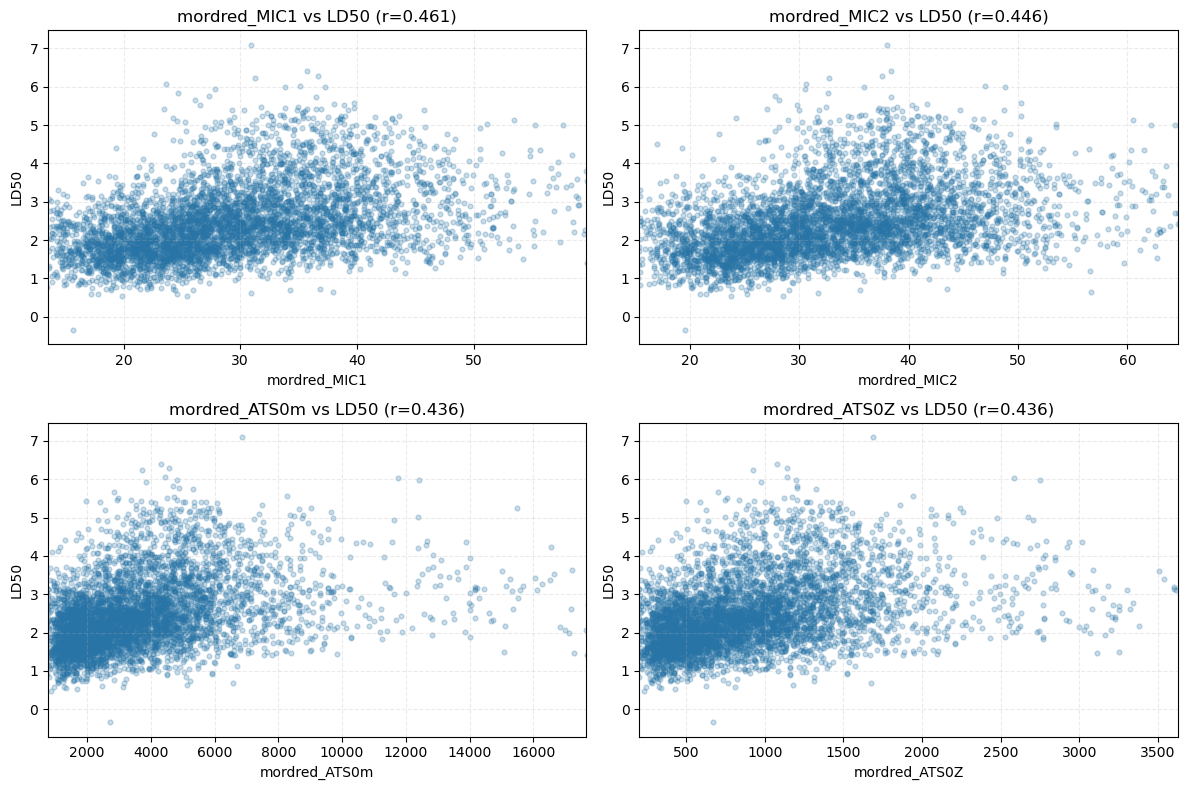

In [9]:
# Scatter plots: Top features vs target
top_features = corr_df.dropna(subset=['corr']).head(4).index.tolist()
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for idx, feat in enumerate(top_features):
    valid_mask = (df[feat].notna()) & (df['Y'].notna())
    x = df[feat][valid_mask]
    y_feat = df['Y'][valid_mask]

    axes[idx].scatter(x, y_feat, alpha=0.25, s=12, color='#2874a6')
    x_low, x_high = np.percentile(x, [1, 99])
    axes[idx].set_xlim(x_low, x_high)

    axes[idx].set_xlabel(feat)
    axes[idx].set_ylabel('LD50')
    corr_val = corr_df.loc[feat, 'corr']
    axes[idx].set_title(f'{feat} vs LD50 (r={corr_val:.3f})')
    axes[idx].grid(alpha=0.25, linestyle='--')

plt.tight_layout()
plt.show()